# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who:** This dataset is designed for Medicaid agencies to measure hospital scale and capacity, resources, financial stability of the hospital

**What:** Examine which hospitals are most critical to Medicaid access by combining capacity (beds/days/discharges/FTEs) with geography (rural/urban, CBSA, county).

**How:** Use the cost report to identify hospitals that are critical to Medicaid access such as those that deliver high inpatient volume and maintain essential capacity (beds and staffing) in geographies where substitutes are limited (rural areas and smaller markets).

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [2]:
df = pd.read_csv(r"C:\Users\Avnish Jadhav\Documents\Boston University\Spring2026\DX699-AI_LEADERS\Hospital_Provider_Cost_Report_2023_updated.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6103 entries, 0 to 6102
Columns: 117 entries, rpt_rec_num to Stand-Alone CHIP Charges
dtypes: float64(103), int64(4), object(10)
memory usage: 5.4+ MB


In [3]:
df.describe()

,rpt_rec_num,Provider CCN,Medicare CBSA Number,Provider Type,Type of Control,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
count,6103.000000,6103.000000,6021.000000,6103.000000,6103.000000,5962.000000,1523.000000,127.000000,5920.000000,5056.000000,...,6.019000e+03,5.799000e+03,6.015000e+03,1.727000e+03,6.014000e+03,4613.000000,4.378000e+03,4.360000e+03,9.520000e+02,9.620000e+02
mean,785008.763559,270290.338358,52928.217074,1.755694,4.178928,977.036184,93.850519,2714.543307,7222.899155,3333.490704,...,-1.069181e+07,2.819683e+07,1.648536e+07,3.628116e+06,1.544624e+07,1.215057,3.348602e+07,2.055063e+08,7.778439e+05,5.644722e+06
std,11943.807349,161725.968794,33991.617314,1.546861,3.194775,4387.357952,168.440715,6731.310188,11807.654450,8131.646390,...,1.276946e+08,1.178323e+08,1.074866e+08,5.424278e+07,1.058836e+08,46.089181,9.327470e+07,4.627638e+08,3.180967e+06,3.569574e+07
min,747534.000000,10001.000000,10180.000000,1.000000,1.000000,0.050000,0.000000,1.000000,1.000000,1.000000,...,-3.979088e+09,-1.693180e+09,-3.955820e+09,-1.234801e+09,-3.955820e+09,0.000000,-2.089892e+07,1.000000e+00,-3.102300e+04,2.120000e+02
25%,775263.500000,140152.500000,26420.000000,1.000000,2.000000,129.080000,8.275000,143.500000,899.000000,103.000000,...,-1.056666e+07,6.939985e+05,-1.570995e+06,-6.000000e+00,-1.702859e+06,0.177129,2.747788e+06,1.098586e+07,2.047800e+04,1.234550e+05
50%,785911.000000,260006.000000,39100.000000,1.000000,2.000000,287.490000,28.620000,885.000000,2561.500000,648.500000,...,-1.335362e+06,3.212208e+06,2.245618e+06,2.153500e+04,2.045326e+06,0.270039,9.313046e+06,5.331015e+07,8.568150e+04,6.043595e+05
75%,794696.500000,393179.000000,99916.000000,1.000000,5.000000,911.427500,92.185000,2552.500000,8762.750000,2883.000000,...,4.753553e+06,1.341372e+07,1.403540e+07,1.104484e+06,1.316970e+07,0.463456,2.902951e+07,2.009139e+08,3.278190e+05,2.354091e+06
max,807303.000000,713029.000000,99966.000000,12.000000,13.000000,295330.130000,1968.000000,59573.000000,208248.000000,183050.000000,...,2.220032e+09,2.658138e+09,2.224171e+09,6.916362e+08,2.224171e+09,3110.668074,3.300915e+09,9.319141e+09,4.598930e+07,8.917134e+08


No duplicates in each row

In [4]:
df.duplicated().sum()

0

The duplicates that would be innapropriate in columns such as **rpt_rec_num (report record number)** . Report record number should be unique per row

In [5]:
rpt_dupes = df.duplicated(subset=["rpt_rec_num"]).sum()
print(f"Record Number duplicates check:{rpt_dupes}")

Record Number duplicates check:0


Dropping NaN's 

In [6]:
def show_null_counts_features(df):
    
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)

    
    feature_types = df.dtypes.apply(
        lambda x: "Numeric" if np.issubdtype(x, np.number) else "Categorical"
    )

    
    missing_data = pd.DataFrame({
        "Feature": count_nulls[count_nulls > 0].index,
        "# Null Values": count_nulls[count_nulls > 0].values,
        "Null %": df_nulls[count_nulls > 0].values,          
        "Type": feature_types[count_nulls > 0].values
    }).sort_values(by="Null %", ascending=False)

    print(f"\nThe dataset contains {len(df):,} samples.\n")

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
        return

    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", None)

    
    missing_data = missing_data.reset_index(drop=True)
    missing_data["Null %"] = missing_data["Null %"].map(lambda x: f"{x:.2f}%")

    print(missing_data.to_string(index=False))


show_null_counts_features(df)



The dataset contains 6,103 samples.

                                                                Feature  # Null Values  Null %        Type
                                        Outlier Payments For Discharges           6103 100.00%     Numeric
                                DRG Amounts Other Than Outlier Payments           6103 100.00%     Numeric
                          Hospital Total Days Title V For Adults & Peds           5987  98.10%     Numeric
                    Hospital Total Discharges Title V For Adults & Peds           5981  98.00%     Numeric
                                               Total Discharges Title V           5981  98.00%     Numeric
                                                     Total Days Title V           5976  97.92%     Numeric
                                                       Notes Receivable           5861  96.03%     Numeric
                                                        Unsecured Loans           5790  94.87%     Numeric

### Dropping columns with NAN values being 100% because the ones less than 100% are going to be imputed

When you run `df.isna()`, you’re basically making a checklist of the dataset:

- **True** = “this cell is missing”
- **False** = “this cell has a value”

Now, when you take `.mean()` on that checklist, pandas treats it like simple math:

- **True acts like 1**
- **False acts like 0**

So the mean becomes **the fraction of rows that are missing** in each column.

- Missing in **25%** of rows → mean is **0.25**
- Missing in **100%** of rows → mean is **1.0**

Then:

- `== 1.0` keeps only columns where **every row is missing**
- `df.columns[...]` returns the **names** of those columns

Bottom line: it gives you a list of columns that are **completely empty** in your file.


In [7]:
empty_cols = df.columns[df.isna().mean() == 1.0]

df_clean = df.drop(columns=empty_cols)
print("Dropped:", len(empty_cols))
print("Empty columns:", empty_cols.tolist())

Dropped: 2
Empty columns: ['DRG Amounts Other Than Outlier Payments', 'Outlier Payments For Discharges']


## Imputing null values < 100%

In [8]:
from sklearn.impute   import SimpleImputer
from sklearn.preprocessing   import OrdinalEncoder, OneHotEncoder  

In [9]:
from sklearn.impute import SimpleImputer

df_imputed = df_clean.copy()

categorical_features = df_imputed.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features     = df_imputed.select_dtypes(include=["number"]).columns.tolist()

# exclude ID-like numeric columns
exclude_numeric = ["rpt_rec_num", "Provider CCN", "Medicare CBSA Number"]
numeric_features = [c for c in numeric_features if c not in exclude_numeric]
print(f"numeric_features:{numeric_features}")
print(f"categorial features: {categorical_features}")

numeric_features:['Provider Type', 'Type of Control', 'FTE - Employees on Payroll', 'Number of Interns and Residents (FTE)', 'Total Days Title V', 'Total Days Title XVIII', 'Total Days Title XIX', 'Total Days (V + XVIII + XIX + Unknown)', 'Number of Beds', 'Total Bed Days Available', 'Total Discharges Title V', 'Total Discharges Title XVIII', 'Total Discharges Title XIX', 'Total Discharges (V + XVIII + XIX + Unknown)', 'Number of Beds + Total for all Subproviders', 'Hospital Total Days Title V For Adults & Peds', 'Hospital Total Days Title XVIII For Adults & Peds', 'Hospital Total Days Title XIX For Adults & Peds', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds', 'Hospital Number of Beds For Adults & Peds', 'Hospital Total Bed Days Available For Adults & Peds', 'Hospital Total Discharges Title V For Adults & Peds', 'Hospital Total Discharges Title XVIII For Adults & Peds', 'Hospital Total Discharges Title XIX For Adults & Peds', 'Hospital Total Discharges (V + XVIII

In [11]:

# impute categorical (most frequent)
cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

# impute numeric (median) EXCEPT excluded columns
num_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

# verify
show_null_counts_features(df_imputed)


The dataset contains 6,103 samples.

             Feature  # Null Values Null %    Type
Medicare CBSA Number             82  1.34% Numeric


**Dropping Rows where Medicare CBSA Number is Null**

In [13]:
df_imputed = df_imputed.dropna(subset=["Medicare CBSA Number"]).copy()
show_null_counts_features(df_imputed)


The dataset contains 6,021 samples.

There are no null values in the dataset!


Class imbalances check 

### GRAPH: Total beds by State (where capacity is concentrated)

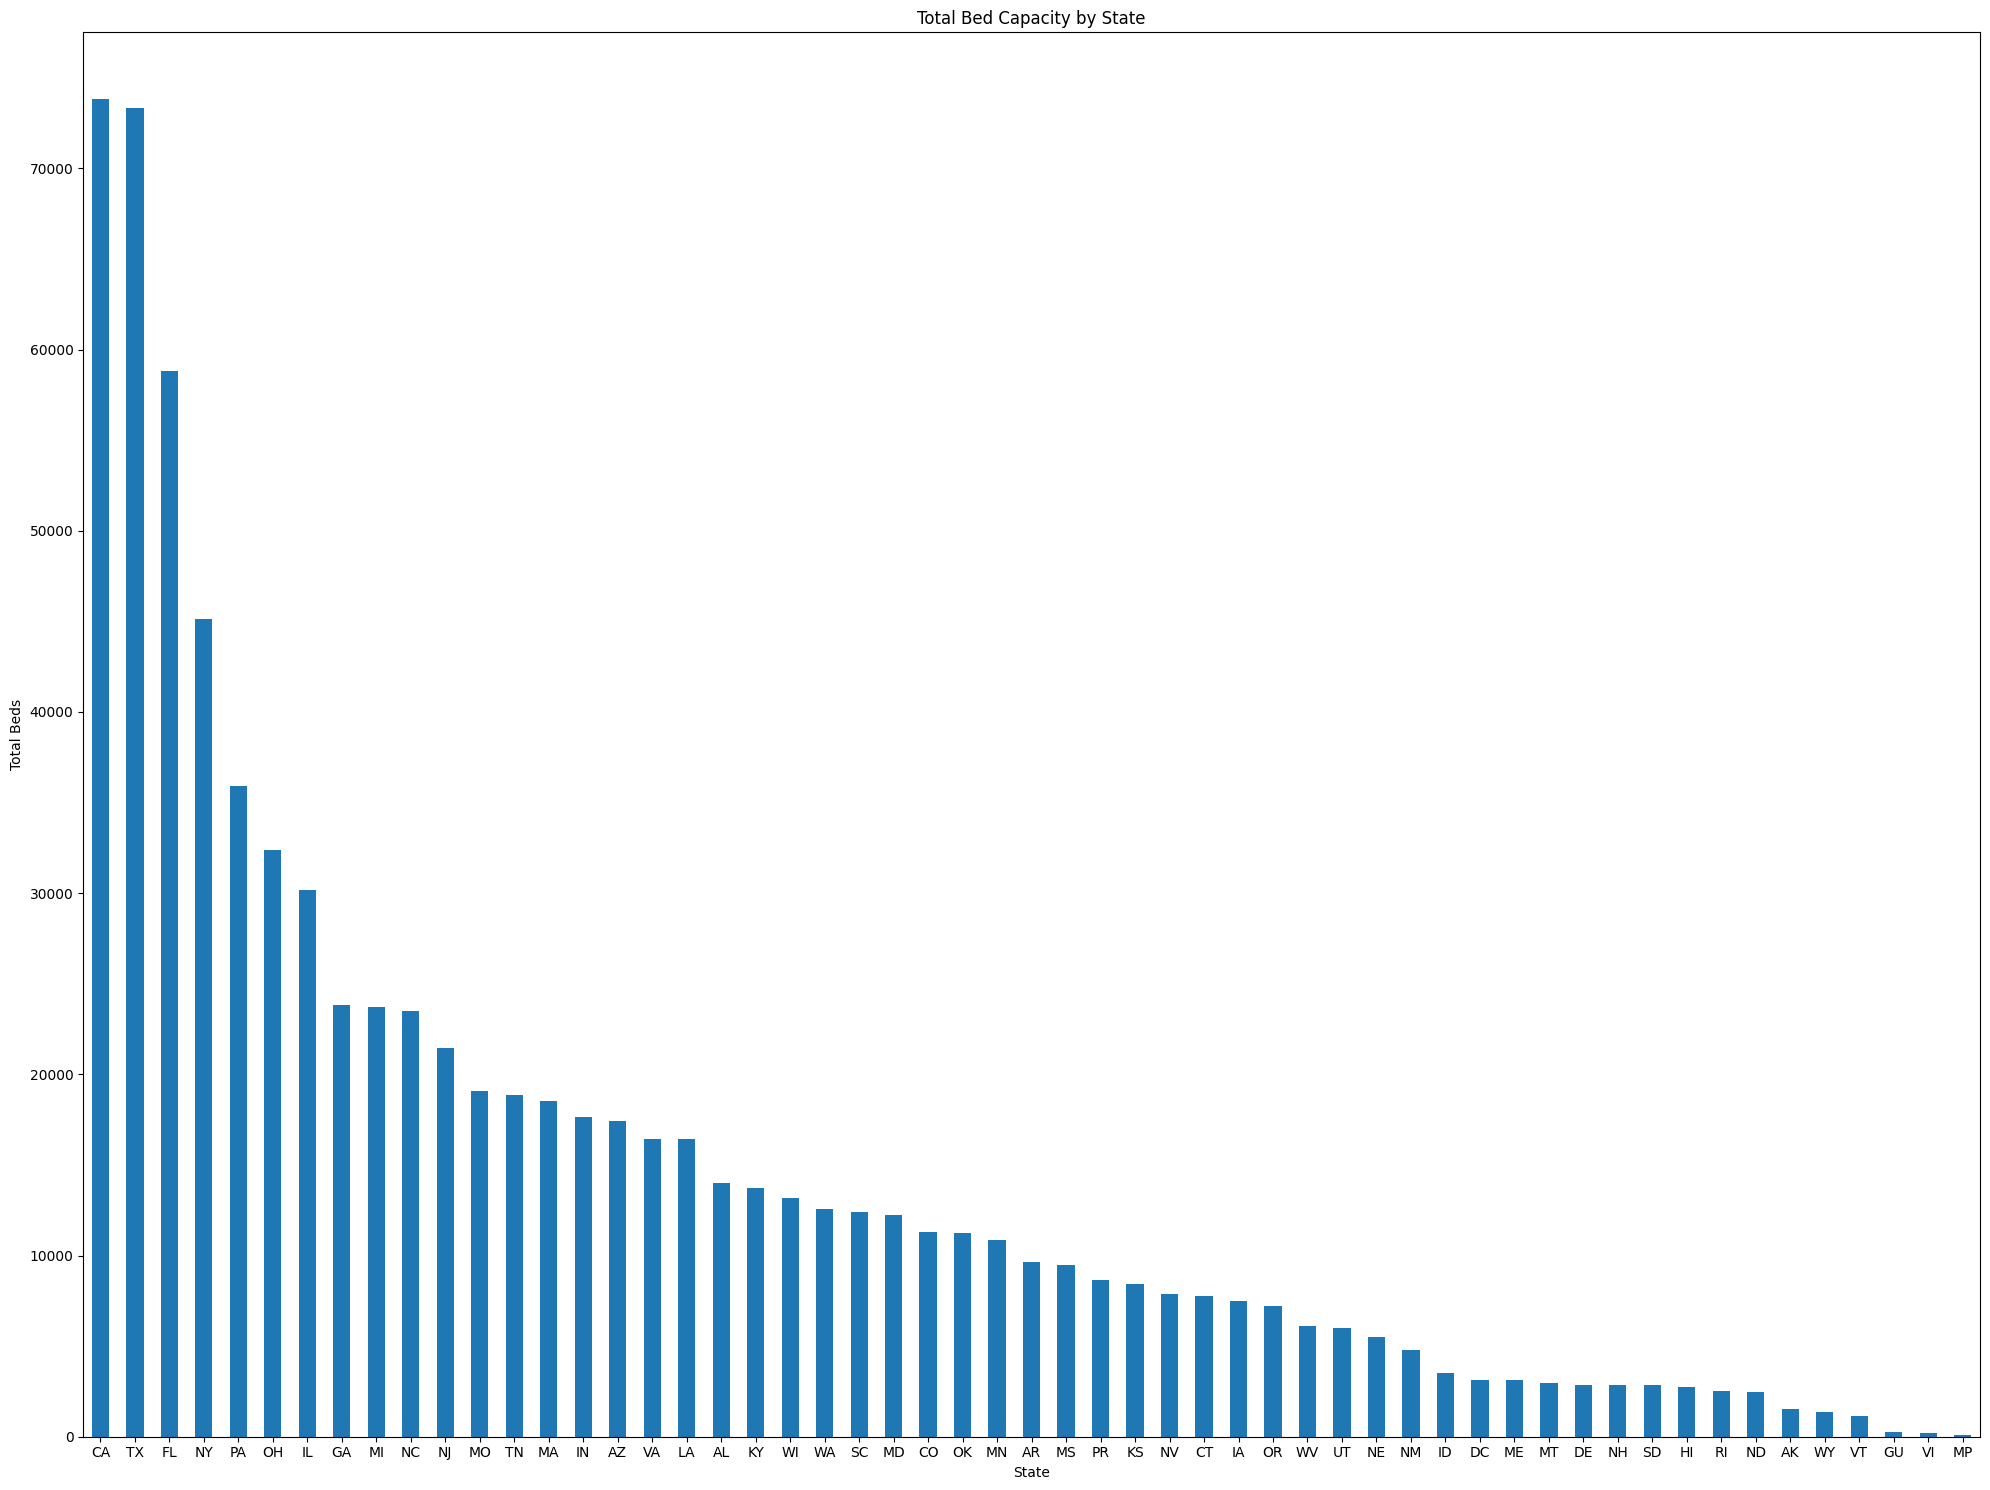

In [34]:
import matplotlib.pyplot as plt

beds = "Number of Beds"
grp = df_imputed.groupby("State Code")[beds].sum().sort_values(ascending=False)

plt.figure(figsize=(20, 15))
ax = grp.plot(kind="bar")
ax.set_title("Total Bed Capacity by State")
ax.set_xlabel("State")
ax.set_ylabel("Total Beds")
plt.xticks(rotation=0)  # states are short; 0 usually reads best
plt.tight_layout()
plt.show()


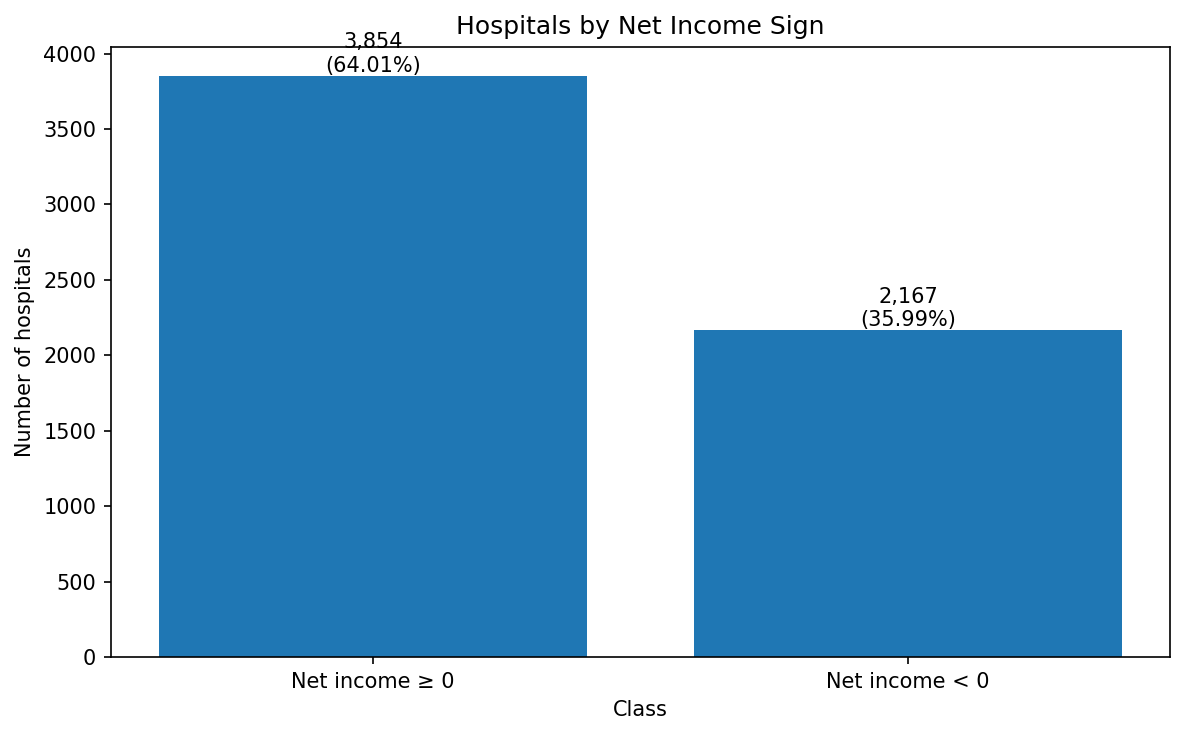

In [41]:
y = (df_imputed["Net Income"] < 0).astype(int)

counts = y.value_counts().sort_index()
pct = (y.value_counts(normalize=True) * 100).round(2).sort_index()

labels = ["Net income ≥ 0", "Net income < 0"]
values = [counts.get(0, 0), counts.get(1, 0)]

plt.figure(figsize=(8, 5), dpi=150)
plt.bar(labels, values)
plt.title("Hospitals by Net Income Sign")
plt.xlabel("Class")
plt.ylabel("Number of hospitals")

total = sum(values)
for i, v in enumerate(values):
    p = (v / total * 100) if total else 0
    plt.text(i, v, f"{v:,}\n({p:.2f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()



## Conclusions

- Before preprocessing and imputing, a noticeable portion of fields have very high missingness (some even 100% null)
- Capacity is not evenly distributed across states
- Hospital net income where 35.99% is in the negative net income whereas 65% are not. Though this is not data class imbalance but shows that 35.99% of hospitals are losing money
- A few states such as California, Texas, and Florida dominate total reported beds (expected given population size and hospital counts)